# 5.0 Model training - LightGBM - Optuna search


## Imports


In [1]:
import numpy as np
import joblib
import json
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_log_error

from recruit_restaurant_visitor_forecasting.config import (
    AIR_RESTAURANT_ID_COL,
    MODELS_DIR,
    VISIT_DATE_COL,
    DAY_OF_WEEK_COL,
    VISITORS_NBR_COL,
    CITY_COL,
    RANDOM_SEED,
)
from recruit_restaurant_visitor_forecasting.dataset import read_csv, DataDir, save_csv
from recruit_restaurant_visitor_forecasting.features import GOLDEN_WEEK_FLG
from recruit_restaurant_visitor_forecasting.modeling.train import (
    load_data,
    prepare_features,
    shap_fs,
    lgbm_optuna_search,
    train_test_split_by_date,
)
from recruit_restaurant_visitor_forecasting.plots import plot_daily_pred
from recruit_restaurant_visitor_forecasting.utils import (
    merge_daily_pred,
    convert_to_serializable,
    get_format,
    optuna_cv_results_to_df,
)
from recruit_restaurant_visitor_forecasting.modeling.predict import recursive_predict

2026-01-18 15:57:26.378 | INFO     | recruit_restaurant_visitor_forecasting.config:<module>:12 - PROJ_ROOT path is: D:\mentoring_program


In [2]:
CV_SPLITS = 5
TEST_SIZE = 0.2
FIRST_ITER_TRIALS = 50
SECOND_ITER_TRIALS = 250
USELESS_FEATURES = [
    *[
        VISITORS_NBR_COL + suffix
        for suffix in ["_mean_7", "_mean_14", "_median_7", "_median_28"]
    ],
    GOLDEN_WEEK_FLG,
]
DROP_COLUMNS = [
    AIR_RESTAURANT_ID_COL,
    VISIT_DATE_COL,
    VISITORS_NBR_COL,
    DAY_OF_WEEK_COL,
    CITY_COL,
    *USELESS_FEATURES,
]

FS_VALID_SIZE = 0.2

MODEL_NAME = "lightgbm_optuna"
MODEL_PATH = MODELS_DIR / f"{MODEL_NAME}_model.pkl"

## Load and prepare

In [3]:
features, labels = load_data()
features = prepare_features(features)
labels = labels.loc[features.index].reset_index(drop=True)
features = features.reset_index(drop=True)

In [4]:
X = features
y = labels

X_train, X_test, y_train, y_test = train_test_split_by_date(
    X, y, date_col=VISIT_DATE_COL, test_size=TEST_SIZE
)

train_dates = X_train[VISIT_DATE_COL]
test_dates = X_test[VISIT_DATE_COL]

print(f"Train set dates: {train_dates.min()} to {train_dates.max()}")
print(f"Test set dates: {test_dates.min()} to {test_dates.max()}")

Train set dates: 2016-02-01 00:00:00 to 2017-01-22 00:00:00
Test set dates: 2017-01-23 00:00:00 to 2017-04-22 00:00:00


## Training

In [5]:
def print_best_params(optuna_study):
    print("Best parameters:", optuna_study.best_params)
    print(f"Best score: {optuna_study.best_value:.5f}")

### Iteration 1

In [6]:
study, model = lgbm_optuna_search(
    X_train,
    y_train,
    n_jobs=6,
    drop_features=DROP_COLUMNS,
    n_trials=FIRST_ITER_TRIALS,
    n_splits=CV_SPLITS,
    random_state=RANDOM_SEED,
)
print_best_params(study)

[I 2026-01-18 14:38:31,510] A new study created in memory with name: no-name-89bacb08-0c49-4c7b-a504-227d673e95d3
[I 2026-01-18 14:38:47,836] Trial 2 finished with value: 0.8486891270490713 and parameters: {'max_depth': 3, 'learning_rate': 0.018898328290140546, 'n_estimators': 148, 'subsample': 0.9191011479503051, 'colsample_bytree': 0.7978249422468474, 'min_child_samples': 15, 'reg_alpha': 0.3264338454441026, 'reg_lambda': 0.005879178951695276, 'num_leaves': 6}. Best is trial 2 with value: 0.8486891270490713.
[I 2026-01-18 14:38:59,962] Trial 3 finished with value: 0.7034385485104884 and parameters: {'max_depth': 5, 'learning_rate': 0.25429591647400435, 'n_estimators': 171, 'subsample': 0.9411389539188868, 'colsample_bytree': 0.5552902484084508, 'min_child_samples': 17, 'reg_alpha': 0.014271438002357363, 'reg_lambda': 0.037610295546570895, 'num_leaves': 25}. Best is trial 3 with value: 0.7034385485104884.
[I 2026-01-18 14:39:01,057] Trial 1 finished with value: 0.7191723968352347 and 

Best parameters: {'max_depth': 5, 'learning_rate': 0.17993938906829932, 'n_estimators': 188, 'subsample': 0.6037736593286098, 'colsample_bytree': 0.5745364989083571, 'min_child_samples': 12, 'reg_alpha': 0.5441480200676205, 'reg_lambda': 2.284439641681787, 'num_leaves': 32}
Best score: 0.69818


In [7]:
optuna_cv_results_to_df(study).sort_values(["rank_test_score"]).head()

,params,std_test_score,mean_test_score,split_test_0,split_test_1,split_test_2,split_test_3,split_test_4,rank_test_score
40,"{'max_depth': 5, 'learning_rate': 0.1799393890...",0.073544,0.698176,0.769693,0.683161,0.628481,0.613233,0.796313,1
41,"{'max_depth': 5, 'learning_rate': 0.1698345790...",0.068847,0.699842,0.769985,0.707440,0.625399,0.617029,0.779355,2
17,"{'max_depth': 5, 'learning_rate': 0.2863216425...",0.079190,0.700732,0.787182,0.713432,0.613715,0.605013,0.784317,3
19,"{'max_depth': 5, 'learning_rate': 0.2659361577...",0.071552,0.702637,0.785189,0.707505,0.624418,0.618665,0.777408,4
37,"{'max_depth': 5, 'learning_rate': 0.1918344935...",0.073231,0.702861,0.777944,0.717891,0.619545,0.615840,0.783087,5


### SHAP feature selection

In [8]:
selected_features, feature_stats = shap_fs(
    X_train,
    y_train,
    model.named_steps["model"],
    drop_features=DROP_COLUMNS,
    test_size=FS_VALID_SIZE,
)

### Iteration 2

In [12]:
study, model_shap = lgbm_optuna_search(
    X_train,
    y_train,
    n_jobs=6,
    drop_features=DROP_COLUMNS,
    n_trials=SECOND_ITER_TRIALS,
    n_splits=CV_SPLITS,
    random_state=RANDOM_SEED,
    features_top=selected_features,
)
print_best_params(study)

[I 2026-01-18 14:57:54,601] A new study created in memory with name: no-name-7ee7f367-408c-4730-9048-54a3f56dd16f
[I 2026-01-18 14:58:02,693] Trial 2 finished with value: 0.7590409974971013 and parameters: {'max_depth': 4, 'learning_rate': 0.05234990233782692, 'n_estimators': 130, 'subsample': 0.5751947489300162, 'colsample_bytree': 0.5682739297264006, 'min_child_samples': 10, 'reg_alpha': 0.00012390188015978925, 'reg_lambda': 5.372908428927479, 'num_leaves': 8, 'keep_count': 10}. Best is trial 2 with value: 0.7590409974971013.
[I 2026-01-18 14:58:04,694] Trial 5 finished with value: 1.157177842982262 and parameters: {'max_depth': 3, 'learning_rate': 0.0016863406615356153, 'n_estimators': 157, 'subsample': 0.554934007831168, 'colsample_bytree': 0.8063847508428506, 'min_child_samples': 23, 'reg_alpha': 0.0001482295694362599, 'reg_lambda': 0.02401743109627277, 'num_leaves': 7, 'keep_count': 21}. Best is trial 2 with value: 0.7590409974971013.
[I 2026-01-18 14:58:16,096] Trial 3 finished 

Best parameters: {'max_depth': 5, 'learning_rate': 0.22222606999837738, 'n_estimators': 239, 'subsample': 0.9671591224623729, 'colsample_bytree': 0.633180228418259, 'min_child_samples': 29, 'reg_alpha': 1.8163538254718266, 'reg_lambda': 0.00021644893140999007, 'num_leaves': 18, 'keep_count': 23}
Best score: 0.68602


In [15]:
cv_results = optuna_cv_results_to_df(study)
cv_results.sort_values(["rank_test_score"]).head()

,params,std_test_score,mean_test_score,split_test_0,split_test_1,split_test_2,split_test_3,split_test_4,rank_test_score
222,"{'max_depth': 5, 'learning_rate': 0.2222260699...",0.070221,0.686019,0.768842,0.684470,0.606003,0.609926,0.760852,1
206,"{'max_depth': 5, 'learning_rate': 0.2033887192...",0.072921,0.687435,0.765540,0.702824,0.608282,0.596953,0.763577,2
208,"{'max_depth': 5, 'learning_rate': 0.2025733469...",0.072578,0.689311,0.775487,0.697157,0.607055,0.605920,0.760934,3
112,"{'max_depth': 5, 'learning_rate': 0.2631088416...",0.071417,0.689350,0.788008,0.699751,0.604707,0.613121,0.741164,4
187,"{'max_depth': 5, 'learning_rate': 0.2066098502...",0.073457,0.689590,0.772317,0.693051,0.605801,0.607456,0.769325,5


### Scores

In [8]:
y_train_pred = model_shap.predict(X_train)
y_train_pred = np.maximum(y_train_pred, 0)

train_rmsle = np.sqrt(mean_squared_log_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"Train set metrics:")
print(f"RMSLE: {train_rmsle:.4f}")
print(f"MAE:  {train_mae:.4f}")

Train set metrics:
RMSLE: 0.8314
MAE:  6.5397


In [6]:
y_test_pred, temp_features = recursive_predict(
    model_shap,
    X_test,
    X_train,
    y_train,
    drop_cols=DROP_COLUMNS,
)

Predicting recursively: 100%|██████████| 90/90 [23:46<00:00, 15.85s/it]


In [7]:
test_rmsle = np.sqrt(mean_squared_log_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f"\nTest set metrics:")
print(f"RMSLE: {test_rmsle:.4f}")
print(f"MAE:  {test_mae:.4f}")


Test set metrics:
RMSLE: 0.8175
MAE:  7.1769
R2:   0.5442


## Graphs

## SHAP explanation

In [19]:
X_test_clean = model_shap.named_steps["feature_dropper"].transform(X_test)
lgbm = model_shap.named_steps["model"]

explainer = shap.TreeExplainer(lgbm)
shap_values = explainer(X_test_clean)

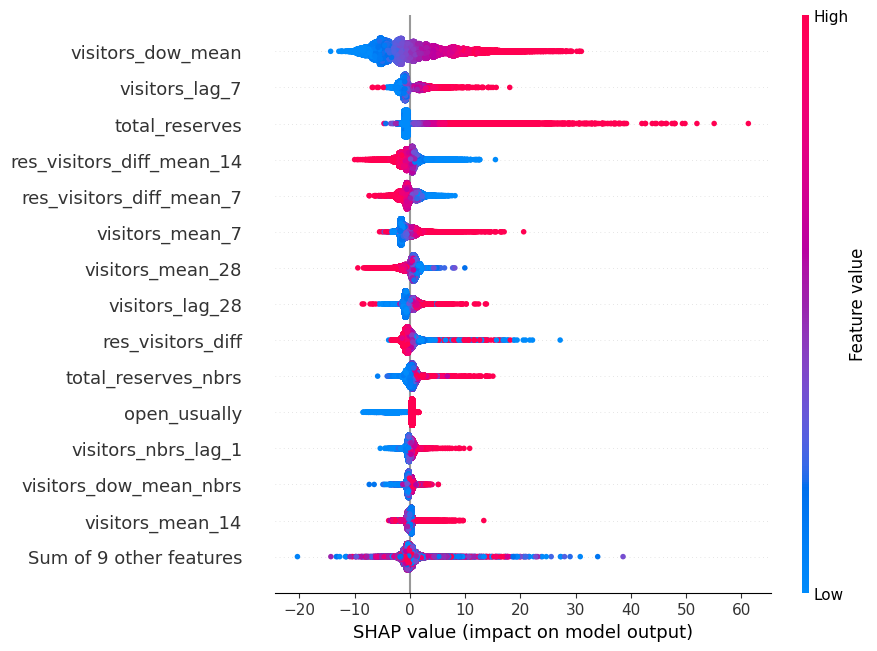

In [20]:
shap.plots.beeswarm(shap_values, max_display=15)

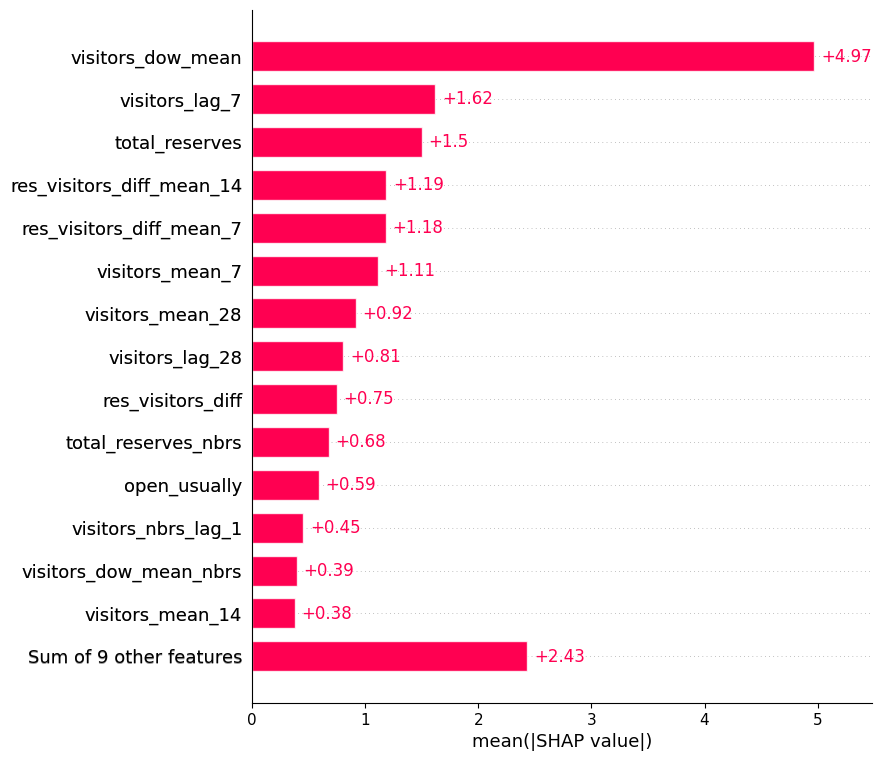

In [21]:
shap.plots.bar(shap_values, max_display=15)

### Visitors per day: actual vs predicted

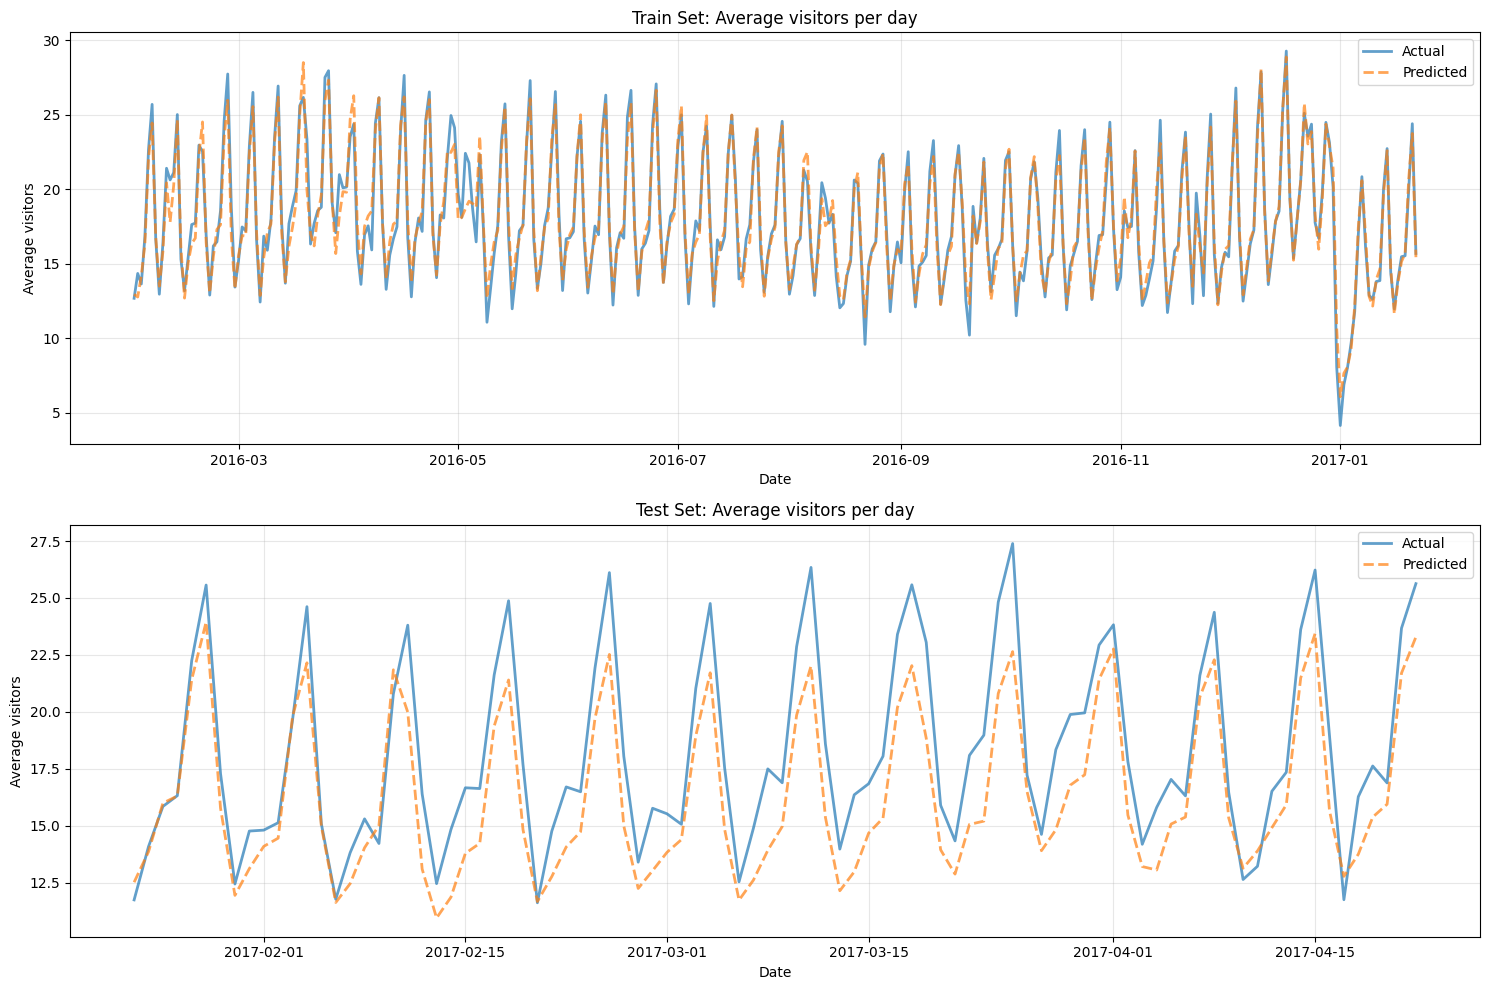

In [9]:
train_daily = merge_daily_pred(train_dates, y_train, y_train_pred)
test_daily = merge_daily_pred(test_dates, y_test, y_test_pred)

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

plot_daily_pred(train_daily, axes[0], train=True)
plot_daily_pred(test_daily, axes[1], train=False)

plt.tight_layout()
plt.show()

## Testing on future data

In [5]:
model_shap = joblib.load(MODEL_PATH)

In [10]:
test_features = read_csv("test_features.csv", DataDir.PROCESSED)
test_features = prepare_features(test_features)

In [11]:
test_labels, temp_features = recursive_predict(
    model_shap,
    test_features,
    X,
    y,
    drop_cols=DROP_COLUMNS,
)

Predicting recursively: 100%|██████████| 39/39 [11:01<00:00, 16.96s/it]


In [12]:
labels_format = get_format(test_features, test_labels)
save_csv(labels_format, "test_labels.csv", DataDir.PROCESSED)

## Saving model

In [23]:
joblib.dump(model_shap, MODEL_PATH)
params_to_save = {
    "best_params": convert_to_serializable(study.best_params),
    "cv_splits": CV_SPLITS,
    "test_size": TEST_SIZE,
    "feature_selection_validation_size": FS_VALID_SIZE,
    "first_iteration_n_trials": FIRST_ITER_TRIALS,
    "second_iteration_n_trials": SECOND_ITER_TRIALS,
    "cv_mean_score": study.best_value,
    "test_score": test_rmsle,
    "std": cv_results.sort_values(["rank_test_score"]).iloc[0]["std_test_score"],
}

PARAMS_PATH = MODELS_DIR / f"{MODEL_NAME}_params.json"
with open(PARAMS_PATH, 'w', encoding='utf-8') as f:
    json.dump(params_to_save, f, indent=2, ensure_ascii=False)